# SHAP comparison: Random Forest vs XGBoost on AqSolDB

Train both models on ECFP bits, compute SHAP values, and compare bit-level importance side by side.


In [2]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit import DataStructs
from rdkit.Chem import rdFingerprintGenerator
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (7, 5)


/Users/michael/dev/delta/qspr-explainability/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Load the dataset (run from qspr directory)
df = pd.read_csv('AqSolDB_v1.0_min.csv')
df = df[['SMILES', 'Solubility']].copy()
print(df.shape)
df.head()


(9982, 2)


,SMILES,Solubility
0,[Br-].CCCCCCCCCCCCCCCCCC[N+](C)(C)C,-3.616127
1,O=C1Nc2cccc3cccc1c23,-3.254767
2,Clc1ccc(C=O)cc1,-2.177078
3,[Zn++].CC(c1ccccc1)c2cc(C(C)c3ccccc3)c(O)c(c2)...,-3.924409
4,C1OC1CN(CC2CO2)c3ccc(Cc4ccc(cc4)N(CC5CO5)CC6CO...,-4.662065


In [4]:
# Convert SMILES to Morgan fingerprints
RADIUS = 2
N_BITS = 100
CHIRAL = True

def smiles_to_mol(smiles: str):
    try:
        return Chem.MolFromSmiles(str(smiles))
    except Exception:
        return None

morgan_generator = rdFingerprintGenerator.GetMorganGenerator(
    radius=RADIUS, fpSize=N_BITS, includeChirality=CHIRAL
)
df['mol'] = df['SMILES'].astype(str).map(smiles_to_mol)
df['ECFP'] = df['mol'].map(lambda mol: morgan_generator.GetFingerprint(mol) if mol is not None else None)
df = df.dropna(subset=['ECFP', 'Solubility']).copy()

X = np.zeros((len(df), N_BITS), dtype=np.int8)
for i, fp in enumerate(df['ECFP']):
    arr = np.zeros((N_BITS,), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    X[i] = arr

target_threshold = df['Solubility'].median()
df['is_soluble'] = (df['Solubility'] >= target_threshold).astype(int)
y = df['is_soluble'].to_numpy()
feature_names = [f'bit_{i}' for i in range(N_BITS)]
print('X shape:', X.shape, 'positive rate:', y.mean())


[11:41:18] WARNING: not removing hydrogen atom without neighbors
[11:41:18] WARNING: not removing hydrogen atom without neighbors
[11:41:18] WARNING: not removing hydrogen atom without neighbors
[11:41:18] WARNING: not removing hydrogen atom without neighbors
[11:41:18] WARNING: not removing hydrogen atom without neighbors
[11:41:18] WARNING: not removing hydrogen atom without neighbors
[11:41:18] WARNING: not removing hydrogen atom without neighbors
[11:41:18] WARNING: not removing hydrogen atom without neighbors
[11:41:18] WARNING: not removing hydrogen atom without neighbors
[11:41:18] WARNING: not removing hydrogen atom without neighbors
[11:41:18] WARNING: not removing hydrogen atom without neighbors
[11:41:18] WARNING: not removing hydrogen atom without neighbors
[11:41:18] WARNING: not removing hydrogen atom without neighbors
[11:41:18] WARNING: not removing hydrogen atom without neighbors
[11:41:18] WARNING: not removing hydrogen atom without neighbors
[11:41:18] WARNING: not r

X shape: (9980, 100) positive rate: 0.5


In [5]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_train.shape, X_test.shape


((6986, 100), (2994, 100))

In [6]:
# Random Forest classifier
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    n_jobs=-1,
    random_state=42,
    class_weight='balanced_subsample'
)
rf.fit(X_train, y_train)

rf_proba = rf.predict_proba(X_test)[:, 1]
rf_pred = (rf_proba >= 0.5).astype(int)
print('RandomForest accuracy:', accuracy_score(y_test, rf_pred))
print('RandomForest ROC AUC:', roc_auc_score(y_test, rf_proba))


RandomForest accuracy: 0.7975951903807615
RandomForest ROC AUC: 0.8715777134317623


In [7]:
# XGBoost classifier
xgb_model = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    n_jobs=-1,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_pred = (xgb_proba >= 0.5).astype(int)
print('XGBoost accuracy:', accuracy_score(y_test, xgb_pred))
print('XGBoost ROC AUC:', roc_auc_score(y_test, xgb_proba))


XGBoost accuracy: 0.799933199732799
XGBoost ROC AUC: 0.8760609618256776


In [8]:
# Compute SHAP values for both models
def to_binary_shap(values):
    arr = np.array(values)
    if arr.ndim == 3 and arr.shape[-1] == 2:
        return arr[:, :, 1]
    if arr.ndim == 3 and arr.shape[0] == 2:
        return arr[1]
    return arr

rf_explainer = shap.TreeExplainer(rf, feature_perturbation='tree_path_dependent', approximate=True)
rf_shap = to_binary_shap(rf_explainer.shap_values(X_test))

xgb_explainer = shap.TreeExplainer(xgb_model, feature_perturbation='tree_path_dependent')
xgb_shap = to_binary_shap(xgb_explainer.shap_values(X_test))

print('RF SHAP shape:', rf_shap.shape)
print('XGB SHAP shape:', xgb_shap.shape)


RF SHAP shape: (2994, 100)
XGB SHAP shape: (2994, 100)


In [9]:
# Aggregate mean(|SHAP|) and relative importance per bit
rf_mean_abs = np.abs(rf_shap).mean(axis=0)
xgb_mean_abs = np.abs(xgb_shap).mean(axis=0)

importance_df = pd.DataFrame({
    'bit': feature_names,
    'rf_mean_abs': rf_mean_abs,
    'xgb_mean_abs': xgb_mean_abs,
})
importance_df['rf_rel'] = importance_df['rf_mean_abs'] / importance_df['rf_mean_abs'].sum()
importance_df['xgb_rel'] = importance_df['xgb_mean_abs'] / importance_df['xgb_mean_abs'].sum()

top_n = 15
importance_df['max_rank'] = importance_df[['rf_mean_abs', 'xgb_mean_abs']].max(axis=1)
top_bits = importance_df.sort_values('max_rank', ascending=False).head(top_n)
top_bits[['bit', 'rf_mean_abs', 'rf_rel', 'xgb_mean_abs', 'xgb_rel']]


,bit,rf_mean_abs,rf_rel,xgb_mean_abs,xgb_rel
11,bit_11,0.025752,0.041646,0.316033,0.043958
91,bit_91,0.030421,0.049197,0.270660,0.037647
69,bit_69,0.033353,0.053939,0.259796,0.036136
3,bit_3,0.022183,0.035875,0.238034,0.033109
39,bit_39,0.013142,0.021253,0.230915,0.032118
8,bit_8,0.029696,0.048025,0.212286,0.029527
75,bit_75,0.027183,0.043960,0.184923,0.025721
27,bit_27,0.015989,0.025857,0.178558,0.024836
78,bit_78,0.017344,0.028048,0.144633,0.020117
45,bit_45,0.022946,0.037108,0.135998,0.018916


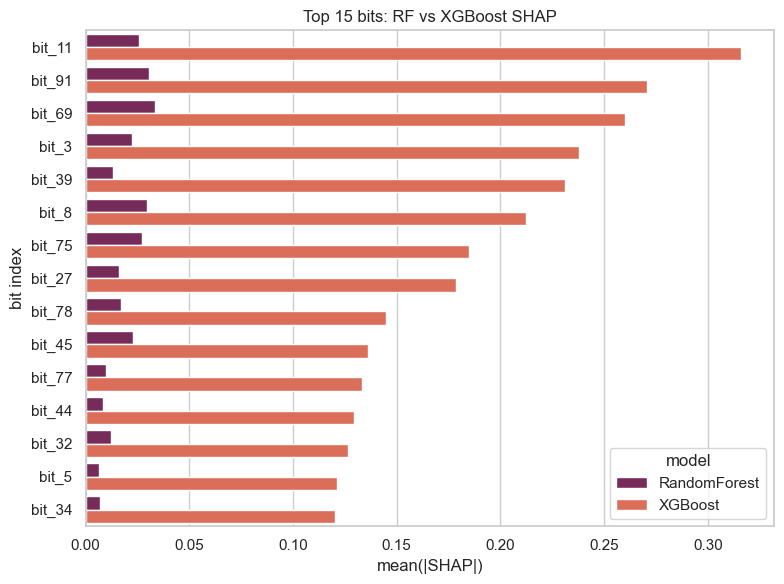

In [10]:
# Side-by-side mean(|SHAP|) for the most important bits
plot_df = top_bits.melt(id_vars='bit', value_vars=['rf_mean_abs', 'xgb_mean_abs'],
                        var_name='model', value_name='mean_abs_shap')
model_labels = {'rf_mean_abs': 'RandomForest', 'xgb_mean_abs': 'XGBoost'}
plot_df['model'] = plot_df['model'].map(model_labels)

plt.figure(figsize=(8, 6))
sns.barplot(data=plot_df, x='mean_abs_shap', y='bit', hue='model', palette='rocket')
plt.xlabel('mean(|SHAP|)')
plt.ylabel('bit index')
plt.title(f'Top {top_n} bits: RF vs XGBoost SHAP')
plt.legend(title='model')
plt.tight_layout()
plt.show()


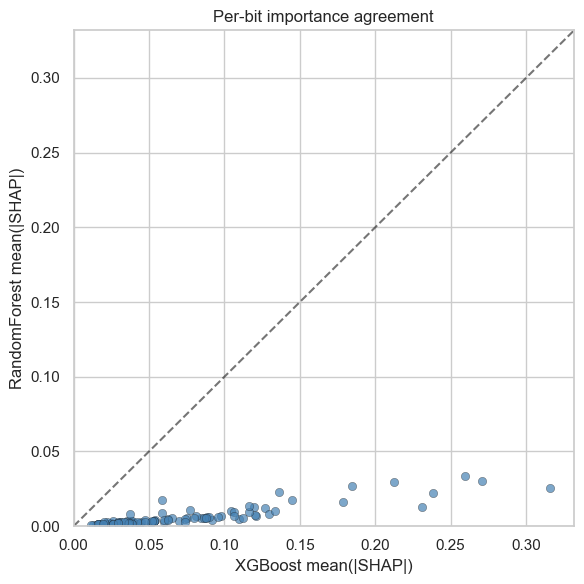

In [11]:
# Scatter comparison of bit importances
plt.figure(figsize=(6, 6))
plt.scatter(xgb_mean_abs, rf_mean_abs, alpha=0.7, color='steelblue', edgecolor='k', linewidth=0.3)
lims = [0, max(xgb_mean_abs.max(), rf_mean_abs.max()) * 1.05]
plt.plot(lims, lims, 'k--', alpha=0.6)
plt.xlim(lims)
plt.ylim(lims)
plt.xlabel('XGBoost mean(|SHAP|)')
plt.ylabel('RandomForest mean(|SHAP|)')
plt.title('Per-bit importance agreement')
plt.tight_layout()
plt.show()


In [12]:
# Inspect the top-ranked bits across both models
top_bits[['bit', 'rf_mean_abs', 'rf_rel', 'xgb_mean_abs', 'xgb_rel']].assign(
    rf_rel_pct=lambda d: d['rf_rel'] * 100,
    xgb_rel_pct=lambda d: d['xgb_rel'] * 100
)


,bit,rf_mean_abs,rf_rel,xgb_mean_abs,xgb_rel,rf_rel_pct,xgb_rel_pct
11,bit_11,0.025752,0.041646,0.316033,0.043958,4.164583,4.395760
91,bit_91,0.030421,0.049197,0.270660,0.037647,4.919680,3.764661
69,bit_69,0.033353,0.053939,0.259796,0.036136,5.393948,3.613558
3,bit_3,0.022183,0.035875,0.238034,0.033109,3.587473,3.310856
39,bit_39,0.013142,0.021253,0.230915,0.032118,2.125317,3.211839
8,bit_8,0.029696,0.048025,0.212286,0.029527,4.802469,2.952732
75,bit_75,0.027183,0.043960,0.184923,0.025721,4.396003,2.572130
27,bit_27,0.015989,0.025857,0.178558,0.024836,2.585687,2.483600
78,bit_78,0.017344,0.028048,0.144633,0.020117,2.804814,2.011723
45,bit_45,0.022946,0.037108,0.135998,0.018916,3.710844,1.891626
